(phillips_self_confirming)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 自我确认均衡

```{index} single: Phillips Curve; Self-Confirming Equilibria
```

```{contents} Contents
:depth: 2
```

除了 Anaconda 中已有的库之外，本讲座还将使用以下库：

In [1]:
!pip install quantecon

## 概述

本讲座完成了 {doc}`phillips_credibility` 中开始研究的*均衡*部分。

它遵循 {cite}`Sargent1999` 的第 7 章，在此之后，本系列将从固定信念转向实时学习的信念。

我们寻求这样一些模型：它们与 {doc}`phillips_credibility` 中 {cite}`KydlandPrescott1977` 的基本模型偏离最小，但同时也让政府的*信念*由其自身政策所产生的数据来塑造。

关键的均衡概念是**自我确认均衡**：政府对菲利普斯曲线可能持有*错误*的模型，但它通过最小二乘法将该模型拟合到数据上，而它所观测到的数据恰好证实了它的信念。

我们结合了两个文献流派的思想：

* {cite}`KingWatson1994` 记录了关于菲利普斯曲线的推断如何取决于*拟合方向*——是将失业率对通货膨胀回归（*古典*识别），还是将通货膨胀对失业率回归（*凯恩斯*识别）。
* 一个可追溯到 Muth、Lucas 和 Prescott 的文献流派 {cite}`muth1961,Lucas_Prescott_1971` 将理性预期均衡表述为从信念到统计模型总体矩的映射的不动点。

我们构建了两个除拟合方向外完全相同的自我确认均衡，并发现最小化的方向会影响结果。

然后我们研究一个**带有误设信念的均衡**，它将 {doc}`phillips_adaptive` 中的费尔普斯问题与 {doc}`phillips_misspecified` 中的最优误设机制结合起来，并发现了乐观的理由：结果优于纳什均衡，并随着政府变得更有耐心而趋近拉姆齐结果。

让我们导入所需的库：

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import quantecon as qe
from scipy.optimize import minimize_scalar

## 费尔普斯问题中的要素

回顾 {doc}`phillips_adaptive` 中一般费尔普斯问题的构成要素。

政府相信一个简约形式的菲利普斯曲线，它可以按两个方向拟合：

$$
\text{古典：} \quad U_t = \gamma^\top X_{C,t} + \varepsilon_{C,t},
\qquad X_{C,t} = \begin{bmatrix} y_t & X_{t-1}^\top \end{bmatrix}^\top,
$$

$$
\text{凯恩斯：} \quad y_t = \beta^\top X_{K,t} + \varepsilon_{K,t},
\qquad X_{K,t} = \begin{bmatrix} U_t & X_{t-1}^\top \end{bmatrix}^\top.
$$

求解费尔普斯问题以政府的信念 $\gamma$ 为给定，得出通货膨胀的决策规则 $h(\gamma)$。

这两种参数化通过如下反演公式相关联

```{math}
:label: sc_invert

\gamma_1 = \beta_1^{-1}, \qquad \gamma_{-1} = - \beta_{-1} / \beta_1 .
```

## 实际菲利普斯曲线

*实际的*菲利普斯曲线在早期讲座使用的基础上进行了扩展，以允许序列相关的冲击：

```{math}
:label: sc_actual

U_t = U^* - \frac{\theta}{1 - \rho_2 L}(y_t - x_t) + \frac{v_{1t}}{1 - \rho_1 L},
```

其中 $|\rho_1| < 1$，$|\rho_2| < 1$，且 $v_t = (v_{1t}, v_{2t})^\top$ 为向量白噪声，其中 $v_{2t} \equiv y_t - x_t$ 是通货膨胀的意外部分。

在本讲座的大部分内容中，我们设 $\rho_1 = \rho_2 = 0$ 以阐明理论要点，这将 {eq}`sc_actual` 化简为

$$
U_t = U^* - \theta(y_t - x_t) + v_{1t} .
$$

## 自我确认均衡

自我确认均衡使政府的信念与这些信念所产生的环境相协调。

```{prf:definition} 自我确认均衡
:label: sc_def

自我确认均衡是一个固定的信念向量 $\gamma$、一条政府决策规则 $h = h(\gamma)$，以及一个 $(y_t, U_t, x_t)$ 的平稳过程，满足

（a）通货膨胀求解费尔普斯问题，$y_t = h X_{t-1} + v_{2t}$；

（b）公众对通货膨胀作出最优预测，$x_t = h X_{t-1}$；

（c）失业率由实际菲利普斯曲线 {eq}`sc_actual` 生成；以及

（d）政府的信念满足最小二乘正交性条件
$\mathbb{E}\left[U_t - \gamma^\top X_{C,t}\right] X_{C,t}^\top = 0$（**古典**拟合方向）。
```

条件（d）使政府的信念依赖于矩矩阵，而这些矩矩阵通过（a）-（c）本身又依赖于政府的信念。

政府的信念隐含着一种行为，该行为产生的数据的矩恰好*证实*了这些信念。

将（d）替换为**凯恩斯**拟合方向，会得到一个不同的自我确认均衡：

> （d′）政府拟合凯恩斯菲利普斯曲线，$\mathbb{E}\left[y_t - \beta^\top X_{K,t}\right] X_{K,t}^\top = 0$，然后通过反演公式 {eq}`sc_invert` 恢复 $\gamma$。

由于政府的信念会影响数据的整个概率分布，最小化的方向会影响结果。

```{note}
一般而言，计算自我确认均衡意味着寻找映射 $\gamma = T(h(\gamma))$
（古典）或 $\beta = S(h(\gamma(\beta)))$（凯恩斯）的不动点。

正交性条件中的矩是通过求解一个离散李雅普诺夫方程，从该系统的状态空间表示中得到的。

实践中，人们迭代一个松弛算法 $\beta_{j+1} = \kappa\beta_j + (1-\kappa) S(\beta_j)$，
这与 {doc}`phillips_credibility` 中的最小二乘学习递归相似。
```

## 手工可解的特殊情形

当 $\rho_1 = \rho_2 = 0$ 时，政府的问题退化为一系列静态问题，每个自我确认均衡都可以手工计算。

令 $X_{t-1} = 1$，实际菲利普斯曲线蕴含以下二阶矩

```{math}
:label: sc_moments

\mathbb{V}[U_t] = \theta^2 \sigma_2^2 + \sigma_1^2,
\qquad
\mathbb{V}[y_t] = \sigma_2^2,
\qquad
\operatorname{cov}(U_t, y_t) = -\theta \sigma_2^2 .
```

**古典拟合方向**（$U$ 对 $y$）：斜率为

$$
\gamma_1 = \frac{\operatorname{cov}(U_t, y_t)}{\mathbb{V}[y_t]} = -\theta,
$$

而均值必须落在回归线上这一要求给出截距 $\gamma_{-1} = (\gamma_1^2 + 1) U^*$。

**凯恩斯拟合方向**（$y$ 对 $U$）：斜率为

$$
\beta_1 = \frac{\operatorname{cov}(U_t, y_t)}{\mathbb{V}[U_t]}
        = \frac{-\theta \sigma_2^2}{\sigma_1^2 + \theta^2 \sigma_2^2},
$$

截距为 $\beta_{-1} = -\frac{\beta_1^2 + 1}{\beta_1} U^*$，由此通过反演得到隐含的古典系数，$\gamma_1 = \beta_1^{-1}$ 和 $\gamma_{-1} = \frac{\beta_1^2 + 1}{\beta_1^2} U^*$。

In [3]:
class SelfConfirmingStatic:
    """
    The two static self-confirming equilibria (ρ1 = ρ2 = 0), one for
    each direction of fit.
    """

    def __init__(self, θ=1.0, U_star=5.0, σ1=0.3, σ2=0.3):
        self.θ, self.U_star, self.σ1, self.σ2 = θ, U_star, σ1, σ2

    def classical(self):
        "Perceived Phillips curve U = γ_{-1} + γ_1 y under classical fit."
        θ, U_star = self.θ, self.U_star
        γ1 = -θ
        γ_1 = (γ1**2 + 1) * U_star
        y_bar = -γ_1 * γ1 / (γ1**2 + 1)      # mean (= Nash) inflation
        return γ1, γ_1, y_bar

    def keynesian(self):
        "Perceived Phillips curve under Keynesian fit, inverted to γ."
        θ, U_star, σ1, σ2 = self.θ, self.U_star, self.σ1, self.σ2
        β1 = -θ * σ2**2 / (σ1**2 + θ**2 * σ2**2)
        β_1 = -(β1**2 + 1) / β1 * U_star
        γ1 = 1 / β1
        γ_1 = (β1**2 + 1) / β1**2 * U_star
        y_bar = β_1 / (β1**2 + 1)             # mean inflation
        return γ1, γ_1, y_bar

In [4]:
sce = SelfConfirmingStatic(θ=1.0, U_star=5.0, σ1=0.3, σ2=0.3)

γ1_C, γ0_C, y_C = sce.classical()
γ1_K, γ0_K, y_K = sce.keynesian()

print("Classical direction of fit")
print(f"  γ_1 = {γ1_C:.1f},  γ_(-1) = {γ0_C:.1f},  mean inflation = {y_C:.1f}")
print("Keynesian direction of fit")
print(f"  γ_1 = {γ1_K:.1f},  γ_(-1) = {γ0_K:.1f},  mean inflation = {y_K:.1f}")

Classical direction of fit
  γ_1 = -1.0,  γ_(-1) = 10.0,  mean inflation = 5.0
Keynesian direction of fit
  γ_1 = -2.0,  γ_(-1) = 25.0,  mean inflation = 10.0


这些结果再现了 {cite}`Sargent1999` 第 7 章中的数值例子。

在古典拟合方向下，平均通货膨胀为纳什值 $\theta U^* = 5$。

在凯恩斯拟合方向下，政府估计出一条*更平坦*的菲利普斯曲线，并相信权衡关系比实际更有利，因此将通货膨胀设定为两倍高，即 $10$。

让我们绘制这两条自我确认的菲利普斯曲线，重现图 7.1。

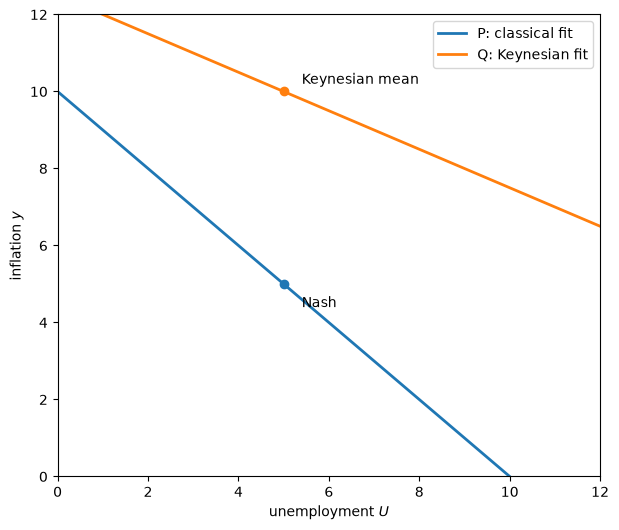

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

U_grid = np.linspace(0, 12, 100)

# perceived Phillips curves U = γ_{-1} + γ_1 y  =>  y = (U - γ_{-1}) / γ_1
ax.plot(U_grid, (U_grid - γ0_C) / γ1_C, 'C0', label='P: classical fit', lw=2)
ax.plot(U_grid, (U_grid - γ0_K) / γ1_K, 'C1', label='Q: Keynesian fit', lw=2)

ax.plot(sce.U_star, y_C, 'C0o')
ax.annotate('Nash', (sce.U_star, y_C), (sce.U_star + 0.4, y_C - 0.6))
ax.plot(sce.U_star, y_K, 'C1o')
ax.annotate('Keynesian mean', (sce.U_star, y_K),
            (sce.U_star + 0.4, y_K + 0.2))

ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.set_xlabel('unemployment $U$')
ax.set_ylabel('inflation $y$')
ax.legend()
plt.show()

曲线 P 是用古典拟合方向估计出的自我确认菲利普斯曲线；曲线 Q 是用凯恩斯拟合方向估计出的。

由于凯恩斯拟合使政府相信权衡关系更可利用，平均通货膨胀更高。

### 为什么不是拉姆齐？

两个自我确认均衡给出的平均结果都*劣于*拉姆齐结果。

这表明 {doc}`phillips_adaptive` 中命题的假设条件出现了失效——该命题原本认为求解费尔普斯问题最终能维持接近拉姆齐的结果。

失效的是**归纳假设**。

由于 $\rho_1 = \rho_2 = 0$，自我确认均衡是序列不相关的，因此滞后通货膨胀会从经验菲利普斯曲线中消失。

停用归纳假设实际上使政府求解一个单期问题，并关闭了促进更好结果的跨期渠道。

## 带有误设信念的均衡

为了探讨施加一个*不同的*错误模型如何可能*改善*纳什结果，我们现在让*公众*而非政府犯一个微妙的设定误差。

这将适应性预期、归纳假设和费尔普斯问题联系了起来。

政府知道正确的模型，

```{math}
:label: sc_bray10

U_t = U^* - \theta(y_t - x_t) + v_{1t},
\qquad
x_t = C y_{t-1} + (1 - C) x_{t-1}, \quad C \in (0, 1),
```

其中公众持有常数增益的适应性预期，参数 $C$ 由其*根据数据进行调整*。

将 $x_t$ 视为状态变量，政府求解费尔普斯问题：通过选择一个反馈规则 $y_t = f_1 + f_2 x_t + v_{2t}$，最大化 $-\mathbb{E}_0 \sum_{t=0}^\infty \delta^t\left[(U^* - \theta(y_t - x_t))^2 + y_t^2\right]$。

这恰好是 {doc}`phillips_adaptive` 中带有适应参数 $\lambda = 1 - C$ 的 LQ 费尔普斯问题。

In [6]:
def phelps_policy(C, δ, θ=1.0, U_star=5.0):
    "Government feedback rule y_t = f1 + f2 x_t, with public gain C."
    λ = 1 - C
    a = np.array([[U_star], [θ]])
    R = 0.5 * (a @ a.T)
    Q = np.array([[0.5 * (θ**2 + 1)]])
    N = -0.5 * θ * a.T
    A = np.array([[1.0, 0.0], [0.0, λ]])
    B = np.array([[0.0], [1 - λ]])
    lq = qe.LQ(Q, R, A, B, N=N, beta=min(δ, 1 - 1e-7))
    P, F, d = lq.stationary_values()
    return -F[0, 0], -F[0, 1]

政府的行为使得*实际*通货膨胀率为

```{math}
:label: sc_bray11

y_t = \frac{f_1}{1 - f_2}
    + \frac{1 - (1 - C)L}{1 - (1 - C(1 - f_2))L} v_{2t}
    = \nu + f(L) v_{2t},
```

均值为 $\nu = f_1 / (1 - f_2)$，谱为 $F(\omega; C) = |f(e^{i\omega})|^2 \sigma_2^2$。

给定 $C$，公众寻求与 {doc}`phillips_misspecified` 中相同形式的最优拟合误设模型，即积分移动平均形式，

$$
y_t = \frac{1 - (1 - c)L}{1 - L}\epsilon_t = g(L)\epsilon_t ,
$$

而由此得出的最优估计映射 $c = B(C)$ 将**预测误设均衡**定义为不动点 $C = B(C)$。

这使得真实模型和近似模型都成为均衡结果，并将适应参数 $C$ 从自由参数转变为一个结果。

In [7]:
class MisspecifiedPhillips:
    """
    Equilibrium with misspecified public beliefs: a fixed point of the
    best-estimate map, with the government solving the Phelps problem.
    """

    def __init__(self, θ=1.0, U_star=5.0, σ2=0.3, δ=0.97, ρ=0.995, N=1024):
        self.θ, self.U_star, self.σ2 = θ, U_star, σ2
        self.δ, self.ρ, self.N = δ, ρ, N
        ω = 2 * np.pi * np.arange(N) / N
        self.z = np.exp(1j * ω)
        self.ω = ω

    def true_process(self, C):
        "Return the mean ν, spectrum F, and policy (f1, f2) given belief C."
        f1, f2 = phelps_policy(C, self.δ, self.θ, self.U_star)
        ν = f1 / (1 - f2)
        ψ = 1 - C * (1 - f2)
        f = (1 - (1 - C) * self.z) / (1 - ψ * self.z)
        F = np.abs(f)**2 * self.σ2**2
        return ν, F, (f1, f2)

    def best_estimate(self, C):
        "The best-estimate map c = B(C)."
        ν, F, _ = self.true_process(C)
        z, ρ = self.z, self.ρ

        def profile(c):
            H = np.abs((1 - (1 - c) * z) / (1 - ρ * z))**2
            σ_ε2 = np.mean(F / H) + ν**2 / H[0]
            return np.log(σ_ε2) + np.mean(np.log(H))

        return minimize_scalar(profile, bounds=(1e-4, 0.99),
                               method='bounded').x

    def solve(self, C0=0.1, tol=1e-10, maxit=500):
        "Iterate the best-estimate map to a fixed point."
        C = C0
        for _ in range(maxit):
            C_new = self.best_estimate(C)
            if abs(C_new - C) < tol:
                break
            C = C_new
        ν, _, (f1, f2) = self.true_process(C_new)
        return C_new, ν, (f1, f2)

In [8]:
mp = MisspecifiedPhillips(δ=0.97)
C_star, ν_star, (f1, f2) = mp.solve()

print(f"equilibrium gain     C = {C_star:.4f}")
print(f"policy rule          y = {f1:.4f} + {f2:.4f} x")
print(f"mean inflation       ν = {ν_star:.3f}")
print(f"Nash inflation   θ U*  = {mp.θ * mp.U_star:.3f}")

equilibrium gain     C = 0.1138
policy rule          y = 0.7109 + 0.3348 x
mean inflation       ν = 1.069
Nash inflation   θ U*  = 5.000


最重要的结果是：隐含的平均通货膨胀率大幅*低于*纳什值 $5$。

嵌入在适应性预期方案中的归纳假设，连同较高的贴现因子，共同带来了这一改进——并且由于 $C$ 现在是一个均衡结果，这一机制比 {doc}`phillips_adaptive` 中更为鲜明，在那里 $C$ 可以独立于 $\delta$ 被操纵。

### 趋近拉姆齐

随着政府变得更有耐心，均衡平均通货膨胀率会降至拉姆齐值零附近。

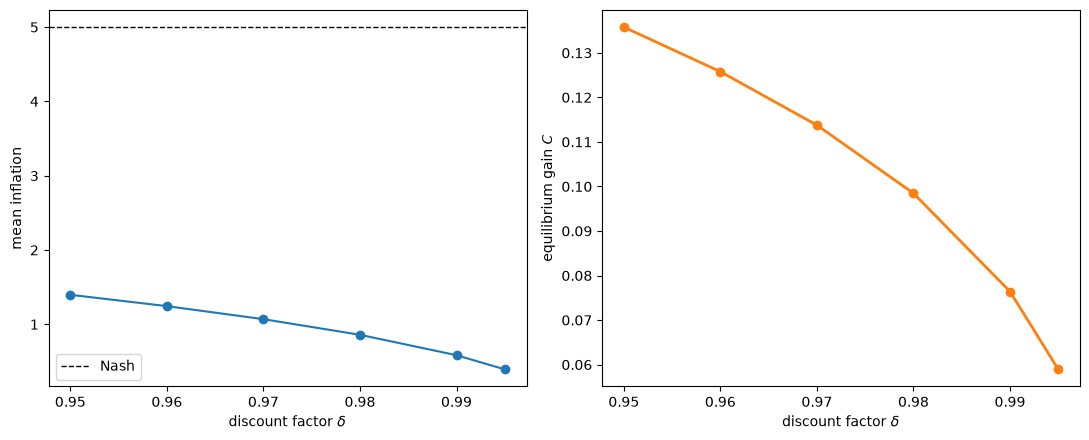

In [9]:
δ_grid = np.array([0.95, 0.96, 0.97, 0.98, 0.99, 0.995])
C_vals, ν_vals = [], []
for δ in δ_grid:
    C, ν, _ = MisspecifiedPhillips(δ=δ).solve()
    C_vals.append(C)
    ν_vals.append(ν)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(δ_grid, ν_vals, 'o-')
axes[0].axhline(mp.θ * mp.U_star, color='k', ls='--', lw=1, label='Nash')
axes[0].set_xlabel(r'discount factor $\delta$')
axes[0].set_ylabel('mean inflation')
axes[0].legend()

axes[1].plot(δ_grid, C_vals, 'o-', color='C1', lw=2)
axes[1].set_xlabel(r'discount factor $\delta$')
axes[1].set_ylabel('equilibrium gain $C$')

plt.tight_layout()
plt.show()

在每个贴现因子下，平均通货膨胀都远低于纳什值，并随着 $\delta \to 1$ 趋近于拉姆齐值零。

```{note}
精确的均衡值取决于用来保证被感知模型谱密度良好定义的近单位根近似 $\rho$，正如
{doc}`phillips_misspecified` 中所讨论的那样。

定性的结论——即结果优于纳什，并随着 $\delta \to 1$ 趋近拉姆齐——是稳健的。
```

### 谱与脉冲响应

让我们比较均衡处真实与近似的通货膨胀过程，如 {cite}`Sargent1999` 的图 7.2 和图 7.3 所示。

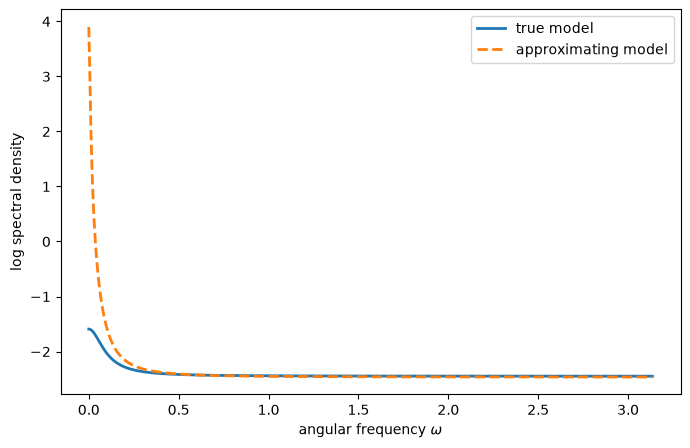

In [10]:
ν_star, F, _ = mp.true_process(C_star)
c_star = mp.best_estimate(C_star)
H = np.abs((1 - (1 - c_star) * mp.z) / (1 - mp.ρ * mp.z))**2
σ_ε2 = np.mean(F / H) + ν_star**2 / H[0]
G = H * σ_ε2

half = mp.N // 2
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mp.ω[:half], np.log(F[:half]), 'C0', label='true model', lw=2)
ax.plot(mp.ω[:half], np.log(G[:half]), 'C1--', label='approximating model', lw=2)
ax.set_xlabel(r'angular frequency $\omega$')
ax.set_ylabel('log spectral density')
ax.legend()
plt.show()

真实谱密度与近似谱密度除了在最低频率处之外都拟合得很好。

真实的通货膨胀率仅具有中等程度的序列相关性，而——正如 {doc}`phillips_misspecified` 中的布雷模型一样——近似模型使用单位根来模拟均值，即用二阶矩来捕捉一阶矩。

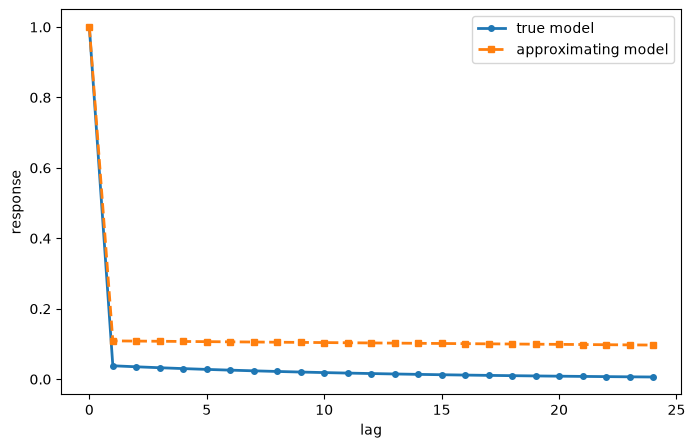

In [11]:
def ima_impulse(num, den, T=25):
    "IRF of (1 - num L)/(1 - den L)."
    h = np.empty(T)
    h[0] = 1.0
    for k in range(1, T):
        h[k] = den * h[k - 1]
    h[1:] -= num * h[:-1]
    return h

ψ = 1 - C_star * (1 - f2)
irf_true = ima_impulse(1 - C_star, ψ)
irf_approx = ima_impulse(1 - c_star, mp.ρ)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(irf_true, 'C0o-', ms=4, label='true model', lw=2)
ax.plot(irf_approx, 'C1s--', ms=4, label='approximating model', lw=2)
ax.set_xlabel('lag')
ax.set_ylabel('response')
ax.legend()
plt.show()

近似模型中的单位根表现为其脉冲响应中的一个非零渐近值。

### 乐观的理由

在自我确认均衡带来失望之后，带有预测误设的均衡令人振奋：它支持了优于纳什的结果。

这个均衡概念不是自我确认的，但它具有那种精神——它体现了一种用*错误*模型进行自我确认的类型。

近似误差之小表明，存在一个近乎自我确认、且结果远优于纳什的模型。

本系列后续的讲座——{doc}`phillips_learning`、{doc}`phillips_escaping_nash` 和 {doc}`phillips_priors`——构建了这些模型的自适应实时版本，其中政府从最新数据中递归地估计其菲利普斯曲线。

在那里，此处计算出的自我确认均衡成为学习动态的*吸引子*，而优于纳什的结果则以反复的*逃逸*现象重新出现，远离该吸引子。

## 练习

```{exercise-start}
:label: sc_ex1
```

两个静态自我确认均衡之间的差距是由方差 $\sigma_1$（菲利普斯曲线冲击）和 $\sigma_2$（通货膨胀意外）驱动的。

古典均衡总是给出等于纳什值 $\theta U^*$ 的平均通货膨胀，但凯恩斯平均通货膨胀取决于比率 $\sigma_1 / \sigma_2$。

固定 $\sigma_2 = 0.3$、$\theta = 1$、$U^* = 5$，绘制凯恩斯平均通货膨胀作为 $\sigma_1 \in [0.05, 1.0]$ 的函数。

当 $\sigma_1 \to 0$ 时会发生什么，为什么？

```{exercise-end}
```

```{solution-start} sc_ex1
:class: dropdown
```

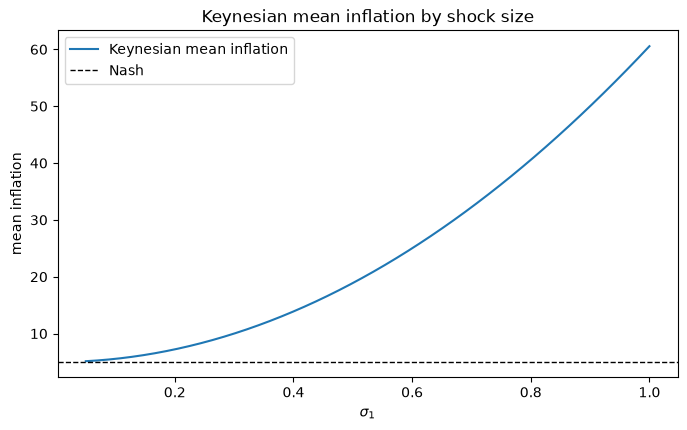

In [12]:
σ1_grid = np.linspace(0.05, 1.0, 50)
y_keynes = [SelfConfirmingStatic(σ1=σ1, σ2=0.3).keynesian()[2]
            for σ1 in σ1_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(σ1_grid, y_keynes, label='Keynesian mean inflation')
ax.axhline(5.0, color='k', ls='--', lw=1, label='Nash')
ax.set_xlabel(r'$\sigma_1$')
ax.set_ylabel('mean inflation')
ax.set_title('Keynesian mean inflation by shock size')
ax.legend()
plt.show()

当 $\sigma_1 \to 0$ 时，菲利普斯曲线趋于近乎确定，凯恩斯斜率 $\beta_1 \to -1/\theta$，两个拟合方向趋于一致，因此凯恩斯平均通货膨胀趋近纳什值。

随着 $\sigma_1$ 增大，失业率变得更嘈杂，$y$ 对 $U$ 的凯恩斯回归变得更平坦，政府感知到一个更可利用的权衡关系，从而提高了平均通货膨胀。

```{solution-end}
```

```{exercise-start}
:label: sc_ex2
```

验证误设信念均衡确实是一个真正的不动点。

对于 $\delta = 0.97$，绘制最优估计映射 $C \mapsto B(C)$ 与 45 度线的关系，并标出不动点。

```{exercise-end}
```

```{solution-start} sc_ex2
:class: dropdown
```

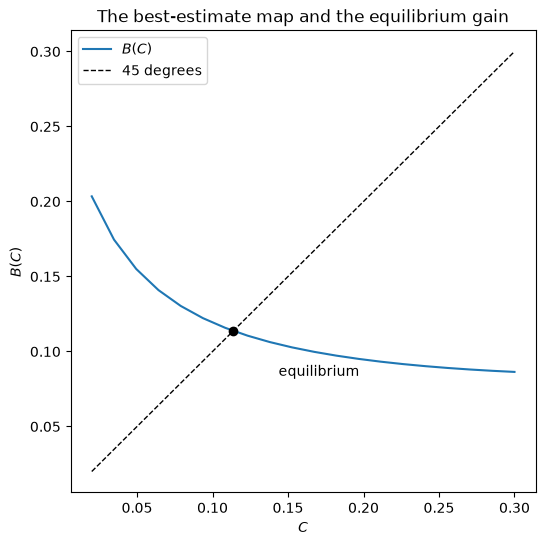

In [13]:
mp = MisspecifiedPhillips(δ=0.97)
C_grid = np.linspace(0.02, 0.3, 20)
B_vals = [mp.best_estimate(C) for C in C_grid]
C_star, _, _ = mp.solve()

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(C_grid, B_vals, 'C0', label='$B(C)$')
ax.plot(C_grid, C_grid, 'k--', lw=1, label='45 degrees')
ax.plot(C_star, C_star, 'ko')
ax.annotate('equilibrium', (C_star, C_star), (C_star + 0.03, C_star - 0.03))
ax.set_xlabel('$C$')
ax.set_ylabel('$B(C)$')
ax.set_title('The best-estimate map and the equilibrium gain')
ax.legend()
plt.show()

最优估计映射在均衡增益处与 45 度线相交，证实了 $C = B(C)$。

```{solution-end}
```